In [6]:
#%matplotlib widget
#importing libraries
from src.MFE import *
from src.MyUlamGalerkin import *
from src.LeichtNewman import *
from src.MST import *
from src.helper import *
from src.visulization import *
from src.SnapCluster import SnapCluster
from src.UlamGalerkin import UlamGalerkin
from src.Dijkstras import *

import time
import numpy as np
import math 
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.widgets import Button, Slider
from matplotlib.animation import FuncAnimation
from matplotlib.animation import FFMpegWriter
from pathlib import Path
from sklearn.cluster import KMeans
import networkx as nx
from collections import Counter
import matplotlib.ticker as mticker
import sys
from joblib import Parallel, delayed
from scipy.optimize import minimize
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
np.set_printoptions(suppress=True) # to avoid scientific notation in numpy printing



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
#Plot Settings


plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['font.family']='serif'

In [8]:
#Start the MFE sequence generation


dt,N,istart =0.05,5600000,10000      # time-step and number of trajectory points
Re=800
Lx,Lz=1.75*np.pi,1.2*np.pi
D,E,a = MFE_Sequence(dt,N,istart,Re,Lx,Lz,a0=[0.9,0,0.187387,0.00000000,0.047047,0,0,0.013188,0])   # generate data sequence 
#t=(np.arange(len(D))+1)*dt
DE = np.vstack((D,E)).T
DE_0=DE.copy()
a_0=a.copy()
caseName=""
Case=create_case_folder(dt,N-istart,Re,Lx,Lz)  
Case = os.path.join(Case, caseName)  

figo, axo = plt.subplots()

t=-1
axo.plot(DE[:, 1], DE[:, 0])
axo.scatter(DE[t, 1], DE[t, 0],c="red",zorder=10)
axo.set_title(f'MFE Sim, dt={dt}, N={N-istart}, Re={Re}')
path = Path(os.path.join(Case, f"DE_N={N-istart}_dt={dt}_Re={Re}.png"))
axo.set_xlabel("Energy")
axo.set_ylabel("Dissipation")
#axo.set_xlim(0,0.3)
#axo.set_ylim(0,3)
#axo.set_facecolor("#EAEBF4")
figo.savefig(path)  
'''
np.savetxt(
    os.path.join(Case, "DE.csv"),
    DE,
    delimiter=",",
    header="D,E",
    comments="",
)
'''
print(F"Time: {dt*(N-istart)}s")

KeyboardInterrupt: 

In [202]:
DE = np.loadtxt("DE_Filled_not_run.csv", delimiter=",", skiprows=1)
a = np.loadtxt("a_Filled_not_run.csv", delimiter=",", skiprows=1)

#DE=DE[::2]
#a= a[::2]
print(DE.shape)
print(a.shape)

(1434717, 2)
(1434717, 9)


In [10]:
idx = [
    np.argmin(DE[:, 0]),
    np.argmax(DE[:, 0]),
    np.argmin(DE[:, 1]),
    np.argmax(DE[:, 1])
]

DE = DE[idx]
a = a[idx]

In [157]:


Disctrize_box_size=30 #Chose the box size for Ulam-Galerkin
sample=2

A= SnapCluster(DE,Disctrize_box_size,sim_time=0,sample_time=sample)
M=A.P
box_idx_list=list(A.Box.keys())
print(min(A.P.sum(axis=0)))

#plot_disctrized_phase_space(DE,Disctrize_box_size)


Time for Ulam-Galerkin Disctrization:1.9694589999999152
Number of boxes: 503
1


In [203]:

def a0_calc_DE(B,chose_box):
    box_value_list=B.BoxVolumeList
    chose_box_value=box_value_list[chose_box]
    D_init=random.uniform(chose_box_value[0], chose_box_value[0]+B.delta[0])
    E_init=random.uniform(chose_box_value[1], chose_box_value[1]+B.delta[1])
    a_opt, res = solve_a0(D_init, E_init)
    return a_opt,res
    

A= SnapCluster(DE,Disctrize_box_size,sim_time=0,sample_time=2)
box_idx_list=list(A.Box.keys())
M=A.P

filled_boxes=M.sum(axis=0)>2000

def generate_data(j):
    if j>=len(A.Box):
        j=j%len(A.Box)
    chose_box=j#np.argmin(M.sum(axis=0))

    #a0_supp=a0_calc(A,chose_box,a)
    a0_supp,res=a0_calc_DE(A,chose_box)
    D_supp,E_supp,a_supp = MFE_Sequence(dt,sample,0,Re,Lx,Lz,a0=a0_supp)
    DE_supp = np.vstack((D_supp,E_supp)).T 

    idx = np.floor((DE_supp - A.mini) / A.delta).astype(int)
    idx_unique,re_index=np.unique(idx,axis=0,return_index=True) 
    mask_res1=np.array([i in re_index for i in  np.random.randint(0,len(re_index),size=len(idx))])  #only take one point from each box
    #print(f"one point mask: {np.sum(mask_res1)}")

    invalid = set(map(tuple, np.array(box_idx_list)[filled_boxes]))
    mask_res2 = np.array([tuple(row) not in invalid for row in idx])                                #only take points from unfilled boxes
    #print(f"filled boxes mask: {np.sum(mask_res2)}")
    
    valid_box = set(map(tuple, np.array(box_idx_list)))
    mask_res3 = np.array([tuple(row) in valid_box for row in idx])                                  #only take points from valid boxes
    #print(f"valid boxes mask: {np.sum(mask_res3)}")
        
    DE_supp=DE_supp[mask_res1&mask_res2&mask_res3]
    a_supp=a_supp[mask_res1&mask_res2&mask_res3]
    return DE_supp,a_supp
for i in range(10):
    results = Parallel(n_jobs=-1,verbose=4)(delayed (generate_data) (j) for j in range(len(A.Box)*1))
    DE_new = np.vstack([r[0] for r in results if r is not None])
    a_new = np.vstack([r[1] for r in results if r is not None])
    DE=np.vstack((DE,DE_new))
    a=np.vstack((a,a_new))
    A=SnapCluster(DE,Disctrize_box_size,sim_time=0,sample_time=2)
    box_idx_list=list(A.Box.keys())
    M=A.P
    filled_boxes=M.sum(axis=0)>2000
print(f"number of points: {len(DE)}")
print(A.P.sum(axis=0))
print(min(A.P.sum(axis=0)))
#print(A.P[:,0])


Time for Ulam-Galerkin Disctrization:2.4894335999852046
Number of boxes: 508


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  66 tasks      | elapsed:    3.8s
[Parallel(n_jobs=-1)]: Done 189 tasks      | elapsed:    9.8s
[Parallel(n_jobs=-1)]: Done 360 tasks      | elapsed:   18.4s
[Parallel(n_jobs=-1)]: Done 508 out of 508 | elapsed:   25.9s finished


Time for Ulam-Galerkin Disctrization:2.294847299985122
Number of boxes: 508


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done 100 tasks      | elapsed:    2.9s
[Parallel(n_jobs=-1)]: Done 346 tasks      | elapsed:    8.6s
[Parallel(n_jobs=-1)]: Done 508 out of 508 | elapsed:   12.9s finished


Time for Ulam-Galerkin Disctrization:2.371399499999825
Number of boxes: 508


...

Time for Ulam-Galerkin Disctrization:2.5372060000081547
Number of boxes: 508


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done 100 tasks      | elapsed:    3.2s
[Parallel(n_jobs=-1)]: Done 346 tasks      | elapsed:    9.4s
[Parallel(n_jobs=-1)]: Done 508 out of 508 | elapsed:   14.1s finished


Time for Ulam-Galerkin Disctrization:2.5523256000014953
Number of boxes: 508


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done 100 tasks      | elapsed:    3.2s
[Parallel(n_jobs=-1)]: Done 346 tasks      | elapsed:    9.4s
[Parallel(n_jobs=-1)]: Done 508 out of 508 | elapsed:   14.2s finished


Time for Ulam-Galerkin Disctrization:2.6281986000249162
Number of boxes: 508
number of points: 1638876
[1572 2075 2046 2063 2005 2008 1758 2002  790  111 2039 2005 2041 2010
 1906 1951 1752 1809 1833 1950 2002 2054 2076 1876 1627 1519 1936  328
  164 2099 2128 2082 2040 2004 1965 1865 1777 1741 1849 1652 1621 1673
 2005 1773 1931 1885 2130 2003 2006 1892 1888 1756 1662  354  296 2008
 1779 1975 2061 2036 1880 1873 1762 1739 1720 1650 1671 1735 1644 1624
 1642 1614 1635 1655 1654 1917 1754 1663 2108 2038 1867 1674  617  441
 1862 1706 1980 1837 1927 1970 1938 1895 1823 1790 1726 1718 1674 1645
 1653 1697 1630 1607 1588 1628 1613 1624 1732 1614 1625 1725  657  493
 1708 1690 1793 1824 1917 1967 1979 1947 1890 1817 1736 1733 1690 1731
 1763 1691 1646 1606 1606 1614 1601 1591 1581 1605 1583  656  598 2493
 1639 1698 1780 1812 1821 1814 1795 1821 1771 1782 1722 1758 1788 1710
 1657 1666 1669 1637 1618 1635 1588 1580 1575  628 1064 2249 1593 1668
 1739 1804 1781 1795 1798 1778 1826 1761 1783

In [217]:
#delete boxes not needed
A= SnapCluster(DE,Disctrize_box_size,sim_time=0,sample_time=2)

DE_min_box_value=random.choices(np.arange(len(DE)), k=int(len(DE)*0.9))
DE = np.delete(DE, DE_min_box_value, axis=0)
a = np.delete(a, DE_min_box_value, axis=0)


Time for Ulam-Galerkin Disctrization:0.07368139998288825
Number of boxes: 508


Text(0, 0.5, 'Dissipation')

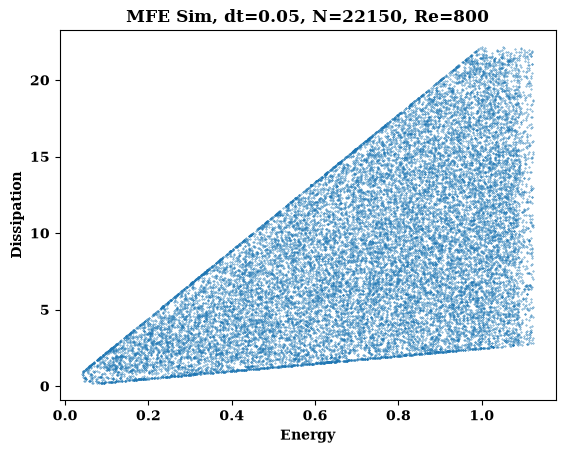

In [218]:

figo, axo = plt.subplots()
axo.scatter(DE[:, 1], DE[:, 0],s=0.1)
#axo.scatter(DE[t, 1], DE[t, 0],c="red",zorder=10,s=0.5)
axo.set_title(f'MFE Sim, dt={dt}, N={len(DE)}, Re={Re}')
axo.set_xlabel("Energy")
axo.set_ylabel("Dissipation")

In [219]:
print(DE.shape)
print(a.shape)

(22150, 2)
(22150, 9)


In [222]:
#generate more data points from DE initial snapshots
sample=2000
sample_start=0
Disctrize_box_size=30 
A= SnapCluster(DE,Disctrize_box_size,sim_time=0,sample_time=sample)
box_idx_list=list(A.Box.keys())
mini = A.mini        
maxi = A.maxi 
#DE=DE[len(DE_0):]
#a=a[len(DE_0):]
def generate_data(a0i):
    
    D_supp, E_supp, a_supp = MFE_Sequence(dt, sample, sample_start, Re, Lx, Lz, a0=a0i)
    DE_supp = np.vstack((D_supp, E_supp)).T


    delta=(maxi+10e-12-mini)/Disctrize_box_size 
    idx = np.floor((DE_supp - mini) / delta).astype(int)

    valid = set(map(tuple, np.array(box_idx_list)))
    mask_res3 = np.array([tuple(row) in valid for row in idx]) #save only points that are in the current boxes
    
    if mask_res3.all():
        return DE_supp, a_supp

results = Parallel(n_jobs=-1,verbose=5)(delayed (generate_data) (a[i]) for i in range(len(DE)))

DE_new = np.vstack([r[0] for r in results if r is not None])
a_new = np.vstack([r[1] for r in results if r is not None])
#DE_new=np.vstack((DE_0,DE_new))
#a_new=np.vstack((a_0,a_new))
#print(DE[0:8])

Time for Ulam-Galerkin Disctrization:0.036356299999170005
Number of boxes: 506


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-1)]: Done 228 tasks      | elapsed:    3.9s
[Parallel(n_jobs=-1)]: Done 1168 tasks      | elapsed:    5.3s
[Parallel(n_jobs=-1)]: Done 2464 tasks      | elapsed:    7.2s
[Parallel(n_jobs=-1)]: Done 4048 tasks      | elapsed:    9.3s
[Parallel(n_jobs=-1)]: Done 5920 tasks      | elapsed:   11.8s
[Parallel(n_jobs=-1)]: Done 8080 tasks      | elapsed:   15.0s
[Parallel(n_jobs=-1)]: Done 10528 tasks      | elapsed:   19.5s
[Parallel(n_jobs=-1)]: Done 13264 tasks      | elapsed:   24.3s
[Parallel(n_jobs=-1)]: Done 16288 tasks      | elapsed:   29.6s
[Parallel(n_jobs=-1)]: Done 19600 tasks      | elapsed:   35.4s
[Parallel(n_jobs=-1)]: Done 22150 out of 22150 | elapsed:   39.9s finished


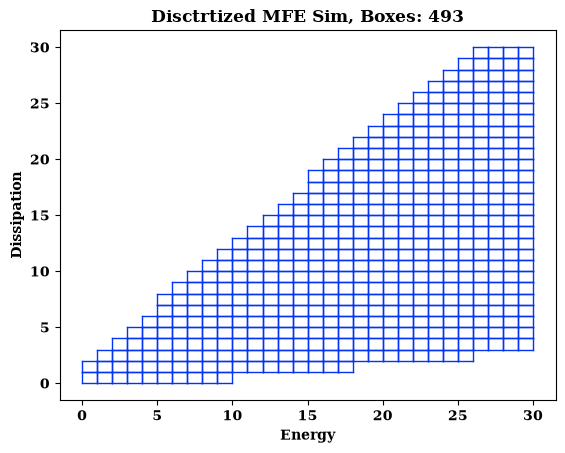

In [131]:
plot_disctrized_phase_space(DE,30)

In [ ]:
#### dont know what to use for see it later 


'''

def a0_calc(B,chose_box,a):
    chose_box_list=list(B.Box.values())
    chose_a=a[chose_box_list[chose_box]]
    
    if len(chose_a) < 2:
        idx=np.random.randint(len(chose_a))
        a0 = chose_a[idx] * (1 + np.random.uniform(-1e-6, 1e-6))
    else:
    
        weights = np.random.rand(2)
        weights /= weights.sum()
        idx=np.random.randint(len(chose_a))
        idx2=np.random.randint(len(chose_a))
        a0=weights[0]*chose_a[idx]+weights[1]*chose_a[idx2]
        
    #print(chose_a)
        weights = np.random.rand(len(chose_a))
        weights /= weights.sum()
        a0 = np.tensordot(weights, chose_a, axes=1)
        
    return a0


def calc_supp(chose_box):
    a0_supp=a0_calc(A,chose_box,a)
    D_supp,E_supp,a_supp = MFE_Sequence(dt,500000,10000,Re,Lx,Lz,a0=a0_supp)
    DE_supp = np.vstack((D_supp,E_supp)).T
    return DE_supp, a_supp


Disctrize_box_size=10 #Chose the box size for Ulam-Galerkin
A= SnapCluster(DE,Disctrize_box_size)
box_idx_list=list(A.Box.keys())
j=0
while min(A.cluster_counts())<100:
    A= SnapCluster(DE,Disctrize_box_size)
    box_idx_list=list(A.Box.keys())
    print(A.cluster_counts())
    if j==len(A.Box):j=0
    chose_box=j
    j+=1
    results = Parallel(n_jobs=-1)(delayed(calc_supp)(chose_box) for _ in range(100));
    for DE_supp, a_supp in results:
        x=DE.copy()      
        mini = np.min(x, axis=0)        #Extract minimum value of all physical variables 
        maxi = np.max(x, axis=0)        #Extract maximum value of all physical variables
        delta=(maxi+10e-12-mini)/Disctrize_box_size            #Discretize the state space into cells
        idx = np.floor((DE_supp - mini) / delta).astype(int)
        unvalid = set(map(tuple, np.array(box_idx_list)[A.cluster_counts()>300]))
        mask_res = np.array([tuple(row) not in unvalid for row in idx])
        DE_supp=DE_supp[mask_res]
        a_supp=a_supp[mask_res]
        DE = np.vstack((DE, DE_supp))
        a = np.vstack((a, a_supp))
print(len(A.Box))
'''

'''
def a0_calc(A,chose_box,a):
    chose_box_list=list(A.Box.values())
    chose_a=a[chose_box_list[chose_box]]
    
    if len(chose_a) < 10:
        idx=np.random.randint(len(chose_a))
        a0 = chose_a[idx] * (1 + np.random.uniform(-1e-6, 1e-6))
    else:
        
        weights = np.random.rand(2)
        weights /= weights.sum()
        idx=np.random.randint(len(chose_a))
        idx2=np.random.randint(len(chose_a))
        a0=weights[0]*chose_a[idx]+weights[1]*chose_a[idx2]


    #print(chose_a)
#        weights = np.random.rand(len(chose_a))
#        weights /= weights.sum()
#        a0 = np.tensordot(weights, chose_a, axes=1)

    #print(a0)
    

    return a0
j=0
A=SnapCluster(DE,Disctrize_box_size,sim_time=N-istart,sample_time=sample)

while min(M.sum(axis=0))<2000:

    #filled_boxes=M.sum(axis=0)>1000
    j+=1
    if j==len(A.Box):
        j=0
    chose_box=len(A.Box)-j#np.argmin(M.sum(axis=0))
    if M.sum(axis=0)[chose_box]>1000:
        continue
    A= SnapCluster(DE,Disctrize_box_size,sim_time=N-istart,sample_time=sample)
    #box_idx_list=list(A.Box.keys())
    M=A.P
    print(M.sum(axis=0))
    print(f"{j},Number of points= {len(DE)}")
    for i in range(1000):
        a0_supp=a0_calc(A,chose_box,a)
        D_supp,E_supp,a_supp = MFE_Sequence(dt,sample,0,Re,Lx,Lz,a0=a0_supp)
        DE_supp = np.vstack((D_supp,E_supp)).T
        
        x=DE.copy()      
        mini = np.min(x, axis=0)        #Extract minimum value of all physical variables 
        maxi = np.max(x, axis=0)        #Extract maximum value of all physical variables
        delta=(maxi+10e-12-mini)/Disctrize_box_size            #Discretize the state space into cells
        idx = np.floor((DE_supp - mini) / delta).astype(int)
        valid = set(map(tuple, np.array(box_idx_list)))
        mask_res = np.array([tuple(row) in valid for row in idx])
        if np.all(mask_res)!=True:
            continue
        
        DE_supp=DE_supp[mask_res]
        a_supp=a_supp[mask_res]
        DE=np.vstack((DE,DE_supp))
        a=np.vstack((a,a_supp))

A=SnapCluster(DE,Disctrize_box_size,sim_time=N-istart,sample_time=sample)
'''

In [223]:
np.savetxt(
    os.path.join("DE_Filled_transients.csv"),
    DE_new,
    delimiter=",",
    header="D,E",
    comments="",
)
np.savetxt(
    os.path.join("a_Filled_transients.csv"),
    a_new,
    delimiter=",",
    header="D,E",
    comments="",
)
print(len(DE_new))

34732000
